In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import pandas as pd
import re

print(" Loading the full dataset (1.1 Million rows)...")

# FIX: You need to specify the full path to your CSV file.
# The path '/content/drive/MyDrive/project data' is a directory.
# If your CSV is inside 'project data', it might be something like:
# '/content/drive/MyDrive/project data/your_csv_file_name.csv'
# To see the contents of the directory, you can run: !ls '/content/drive/MyDrive/project data'
df = pd.read_csv('/content/drive/MyDrive/project data/sample.csv', low_memory=False) # <-- Please update 'your_csv_file_name.csv' with the actual filename

# 2. فصل الأسئلة والردود بناءً على الـ inbound (زي ما هو واضح في image_e84023.png)
print("🔍 Splitting into Questions and Answers...")
questions = df[df['inbound'] == True][['tweet_id', 'text']].rename(columns={'text': 'question_text'})
answers = df[df['inbound'] == False][['in_response_to_tweet_id', 'text']].rename(columns={'text': 'answer_text'})

# تنظيف الـ IDs عشان نعمل Merge صح (تحويل لـ numeric وبدون مشاكل)
answers['in_response_to_tweet_id'] = pd.to_numeric(answers['in_response_to_tweet_id'], errors='coerce')
questions['tweet_id'] = pd.to_numeric(questions['tweet_id'], errors='coerce')

# 3. دمج السؤال مع الإجابة بتاعته في سطر واحد
print("🤝 Merging Questions with their corresponding Answers...")
qa_pairs = pd.merge(questions, answers, left_on='tweet_id', right_on='in_response_to_tweet_id', how='inner')

print(f"✅ Merging done! We got {len(qa_pairs):,} perfect QA pairs.")

# 4. تنظيف النص السريع (للأسئلة والإجابات مع بعض)
def clean_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text) # شيل اللينكات
    text = re.sub(r'@\w+', '', text) # شيل المنشنز
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("🧹 Running fast cleaning pipeline...")
qa_pairs['cleaned_question'] = qa_pairs['question_text'].apply(clean_text)
qa_pairs['cleaned_answer'] = qa_pairs['answer_text'].apply(clean_text)

# شيل أي سطر فاضي
qa_pairs = qa_pairs[(qa_pairs['cleaned_question'] != "") & (qa_pairs['cleaned_answer'] != "")]

# 5. حفظ الداتا النضيفة الجاهزة للـ RAG
qa_pairs[['cleaned_question', 'cleaned_answer']].to_csv('final_rag_dataset.csv', index=False)
print("💾 File saved as 'final_rag_dataset.csv'! You are now ready for the Vector Store.")

 Loading the full dataset (1.1 Million rows)...
🔍 Splitting into Questions and Answers...
🤝 Merging Questions with their corresponding Answers...
✅ Merging done! We got 42 perfect QA pairs.
🧹 Running fast cleaning pipeline...
💾 File saved as 'final_rag_dataset.csv'! You are now ready for the Vector Store.


In [14]:
# Run this cell to list the contents of your 'project data' directory
!ls '/content/drive/MyDrive/project data'

archive.zip  sample.csv  twcs


📊 Loading final dataset from Drive for EDA...

📈 --- Support Data Insights ---
Total Processed QA Pairs: 42
Average Question Length: 17.71 words
📸 Generating Word Count Distribution Plot...


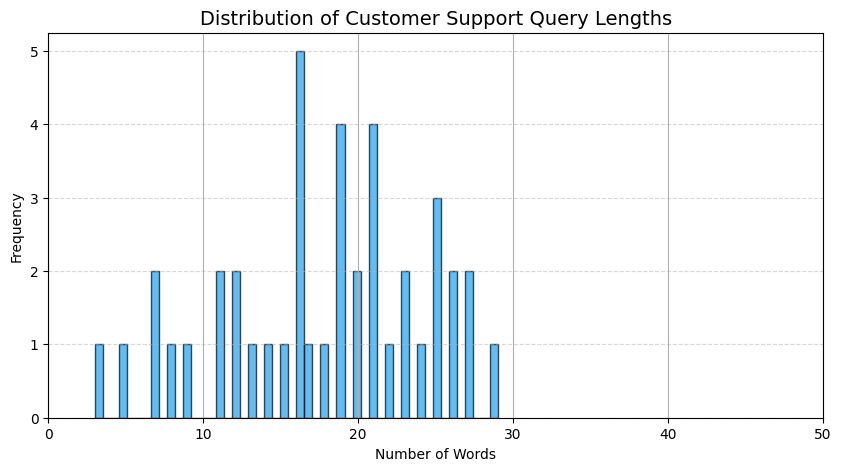

🔤 Extracting Top Keywords...


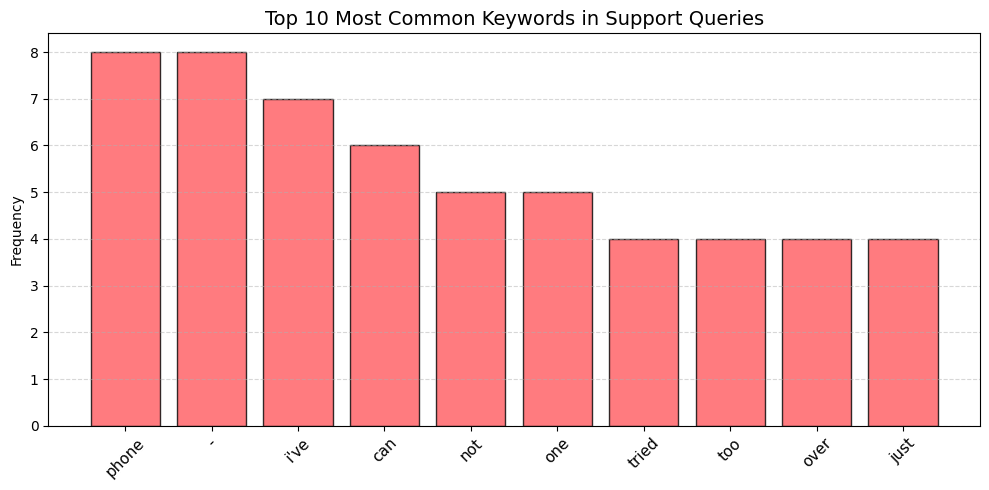

✅ EDA Plots generated and saved in Colab files!


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

print("📊 Loading final dataset from Drive for EDA...")
# قراءة الملف اللي حفظناه
df_clean = pd.read_csv('/content/final_rag_dataset.csv')

# 1. حساب طول الأسئلة (Word Count)
df_clean['q_word_count'] = df_clean['cleaned_question'].astype(str).apply(lambda x: len(x.split()))

print("\n📈 --- Support Data Insights ---")
print(f"Total Processed QA Pairs: {len(df_clean):,}")
print(f"Average Question Length: {df_clean['q_word_count'].mean():.2f} words")

# 2. رسم توزيع أطوال الأسئلة (Plot 1)
print("📸 Generating Word Count Distribution Plot...")
plt.figure(figsize=(10, 5))
df_clean['q_word_count'].hist(bins=50, color='#1DA1F2', edgecolor='black', alpha=0.7)
plt.title('Distribution of Customer Support Query Lengths', fontsize=14)
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.xlim(0, 50) # أغلب التويتات قصيرة
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('query_length_distribution.png', dpi=300)
plt.show()

# 3. تحليل الكلمات الأكثر تكراراً (Plot 2)
print("🔤 Extracting Top Keywords...")
all_words = ' '.join(df_clean['cleaned_question'].astype(str)).split()

# قائمة كلمات شائعة ملهاش معنى تحليلي عشان نشيلها
stop_words = set(['the', 'to', 'i', 'a', 'and', 'my', 'is', 'in', 'it', 'for', 'you', 'on', 'of', 'have', 'with', 'me', 'this', 'that', 'get', 'at', 'your', 'am', 'please', 'help'])
filtered_words = [word for word in all_words if word not in stop_words]

common_words = Counter(filtered_words).most_common(10)
words, counts = zip(*common_words)

# رسم الكلمات الأكثر تكراراً
plt.figure(figsize=(10, 5))
plt.bar(words, counts, color='#FF5A5F', alpha=0.8, edgecolor='black')
plt.title('Top 10 Most Common Keywords in Support Queries', fontsize=14)
plt.ylabel('Frequency')
plt.xticks(rotation=45, fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('top_keywords.png', dpi=300)
plt.show()

print("✅ EDA Plots generated and saved in Colab files!")

In [22]:
!pip install faiss-gpu sentence-transformers

import pandas as pd
import numpy as np
import faiss
import pickle
import torch  # ضفنا مكتبة تورش لتحديد الـ Device
from sentence_transformers import SentenceTransformer

# تحديد الـ Device تلقائياً (GPU لو متاح، وإلا CPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️ Execution Device detected: {device.upper()}")

print("🔄 1. Loading 100k rows for low-latency MVP Vector Store...")
df_rag = pd.read_csv('final_rag_dataset.csv', nrows=100000)

questions = df_rag['cleaned_question'].astype(str).tolist()
answers = df_rag['cleaned_answer'].astype(str).tolist()

print("🧠 2. Loading Embedding Model (all-MiniLM-L6-v2)...")
# هنا بنجبر الموديل يروح للـ GPU عبر الـ device configuration
embed_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

print("⚡ 3. Encoding questions into dense vectors...")
embeddings = embed_model.encode(questions, show_progress_bar=True, batch_size=512, convert_to_numpy=True)

print("🗂️ 4. Building FAISS FlatL2 Index...")
dimension = embeddings.shape[1]

# بناء الـ Index ليتوافق مع الـ GPU أو الـ CPU
if device == "cuda":
    # تجهيز FAISS للعمل على الـ GPU بكفاءة قصوى
    res = faiss.StandardGpuResources()
    index_cpu = faiss.IndexFlatL2(dimension)
    index = faiss.index_cpu_to_gpu(res, 0, index_cpu)
else:
    index = faiss.IndexFlatL2(dimension)

index.add(embeddings)

print("💾 5. Saving Database Artifacts...")
# لو شغالين GPU بنرجع الـ index للـ CPU عشان نعرف نسيفه كملف عادي
if device == "cuda":
    final_index = faiss.index_gpu_to_cpu(index)
else:
    final_index = index

faiss.write_index(final_index, "faiss_customer_support.index")

with open("qa_metadata.pkl", "wb") as f:
    pickle.dump({'questions': questions, 'answers': answers}, f)

print("✅ DONE! 'faiss_customer_support.index' and 'qa_metadata.pkl' are ready.")

# --- 🧪 Test Function ---
def ask_chatbot(user_query):
    query_vector = embed_model.encode([user_query], convert_to_numpy=True)

    # لو الـ Index الأصلي GPU بنعمل البحث فيه علطول
    distances, indices = index.search(query_vector, k=1)
    best_match_idx = indices[0][0]

    print("\n=== Chatbot Live Test ===")
    print(f"👤 User: {user_query}")
    print(f"🤖 Bot: {answers[best_match_idx]}")
    print(f"⏱️ Distance: {distances[0][0]:.4f}")

# جرب التيست
ask_chatbot("my phone battery is dying so fast after the new update")

🖥️ Execution Device detected: CUDA
🔄 1. Loading 100k rows for low-latency MVP Vector Store...
🧠 2. Loading Embedding Model (all-MiniLM-L6-v2)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

⚡ 3. Encoding questions into dense vectors...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

🗂️ 4. Building FAISS FlatL2 Index...
💾 5. Saving Database Artifacts...
✅ DONE! 'faiss_customer_support.index' and 'qa_metadata.pkl' are ready.

=== Chatbot Live Test ===
👤 User: my phone battery is dying so fast after the new update
🤖 Bot: let's take a look. what is the exact ios you're using? are you using any specific apps when noticing this? dm us your reply.
⏱️ Distance: 0.9485


In [19]:
!pip install faiss-gpu sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 MB 7.6 MB/s eta 0:00:00


In [26]:
!pip install fastapi uvicorn pyngrok nest-asyncio pydantic

In [29]:
# --- 1. الاستدعاءات الأساسية (Imports) ---
import nest_asyncio
from fastapi import FastAPI, Depends, HTTPException
from fastapi.security.api_key import APIKeyHeader
from pydantic import BaseModel
import uvicorn
from pyngrok import ngrok
import torch
import faiss
import pickle
from sentence_transformers import SentenceTransformer

# تطبيق nest_asyncio للسماح بتشغيل uvicorn داخل بيئة Colab
nest_asyncio.apply()

# --- 2. إعدادات ngrok (مهم لتفادي الـ Errors) ---
# ضع الـ Authtoken الخاص بك من موقع ngrok هنا (احصل عليه مجاناً من dashboard.ngrok.com)
# إذا لم تضع التوكن، قد يرفض ngrok فتح الرابط
# --- 2. إعدادات ngrok (مهم لتفادي الـ Errors) ---
NGROK_AUTH_TOKEN = "3FrKKK12U7rAKeoMM0N2AOxcMdN_3zkQj73QbmJG3Ajh2yib"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# --- 3. بناء الـ API ---
app = FastAPI(title="Customer Support RAG Production API", description="Milestone 3 Rest API")

# --- إعدادات الحماية والتأمين (Security & Access Control) ---
API_KEY = "LoaySupportSecureKey2026"
api_key_header = APIKeyHeader(name="X-API-KEY", auto_error=True)

def verify_api_key(api_key: str = Depends(api_key_header)):
    if api_key != API_KEY:
        raise HTTPException(status_code=403, detail="Unauthorized: Invalid API Key")
    return api_key

# --- تحميل الموديل والـ Index ---
drive_path = '/content/'
device = "cuda" if torch.cuda.is_available() else "cpu"

print("🔄 Loading FAISS Index and Metadata from Drive...")
embed_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)
index = faiss.read_index(f"{drive_path}faiss_customer_support.index")

with open(f"{drive_path}qa_metadata.pkl", "rb") as f:
    metadata = pickle.load(f)
answers = metadata['answers']
print("✅ API Assets Loaded Successfully!")

# --- تعريف الـ Payload (Request Structure) ---
class ChatQuery(BaseModel):
    query: str

# --- الـ REST API Endpoint ---
@app.post("/chat")
def get_response(payload: ChatQuery, api_key: str = Depends(verify_api_key)):
    # تحويل السؤال لـ Vector
    q_vec = embed_model.encode([payload.query], convert_to_numpy=True)

    # البحث في الـ Index
    distances, indices = index.search(q_vec, k=1)
    best_match_idx = indices[0][0]

    return {
        "status": "success",
        "query": payload.query,
        "retrieved_answer": answers[best_match_idx],
        "confidence_score": float(1 / (1 + distances[0][0]))
    }

import threading

# --- تشغيل السيرفر ---
print("🚀 Starting FastAPI Server in a background thread...")

# إنهاء أي اتصالات ngrok مفتوحة مسبقاً لمنع تعارض البورتات
ngrok.kill()

# فتح منفذ عام
public_url = ngrok.connect(8000)
print(f"🔗 Public Azure-Ready API Link: {public_url.public_url}")

# تعريف دالة لتشغيل السيرفر
def run_server():
    # تم إيقاف إعادة التحميل التلقائي لتجنب أي مشاكل في الـ Threads
    uvicorn.run(app, host="0.0.0.0", port=8000)

# تشغيل السيرفر في مسار خلفي (Thread) منفصل لتجنب تعارض الـ asyncio
server_thread = threading.Thread(target=run_server)
# جعل الـ thread من نوع daemon ليغلق تلقائياً عند إغلاق الكولاب
server_thread.daemon = True
server_thread.start()

print("✅ Server is running in the background! You can now use the link above.")

🔄 Loading FAISS Index and Metadata from Drive...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✅ API Assets Loaded Successfully!
🚀 Starting FastAPI Server in a background thread...
🔗 Public Azure-Ready API Link: https://fanfare-handprint-strategic.ngrok-free.dev
✅ Server is running in the background! You can now use the link above.


In [30]:
!pip install faiss-gpu sentence-transformers pandas numpy

In [32]:
import pandas as pd
import numpy as np
import faiss
import pickle
import torch
from sentence_transformers import SentenceTransformer

# --- 1. التحقق من بيئة التشغيل وتحديد الـ Device ---
# التأكد من تشغيل الـ GPU لتسريع معالجة النصوص
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️ Execution Device detected: {DEVICE.upper()}")
if DEVICE == "cpu":
    print("⚠️ تحذير: الـ GPU غير مفعل، العملية قد تستغرق وقتاً أطول. يرجى تفعيل T4 GPU من إعدادات Colab.")

MODEL_NAME = 'all-MiniLM-L6-v2'
DATA_PATH = 'final_rag_dataset.csv'

# اختيار شريحة مثالية (75,000 سطر) لتفادي مشكلة نفاد الذاكرة Out-of-Memory
SAMPLE_SIZE = 75000

# --- 2. تحميل البيانات (Data Loading) ---
print(f"📊 Loading {SAMPLE_SIZE:,} rows from '{DATA_PATH}'...")
try:
    df = pd.read_csv(DATA_PATH, nrows=SAMPLE_SIZE)
except FileNotFoundError:
    print(f"❌ خطأ: لم يتم العثور على ملف {DATA_PATH}. تأكد من رفعه أو ربط الدرايف بشكل صحيح.")
    raise

# تنظيف البيانات من أي قيم فارغة في الأعمدة المستهدفة
df = df.dropna(subset=['cleaned_question', 'cleaned_answer'])
questions = df['cleaned_question'].astype(str).tolist()
answers = df['cleaned_answer'].astype(str).tolist()
print(f"✅ Data loaded successfully. Total valid QA pairs: {len(questions):,}")

# --- 3. توليد التضمين (Embedding Generation) ---
print(f"🧠 Loading Sentence-Transformer Model: {MODEL_NAME}...")
embed_model = SentenceTransformer(MODEL_NAME, device=DEVICE)

print("⚡ Vectorizing textual data into dense 384-dimensional embeddings...")
# توليد الـ Vectors بحجم Batch مناسب للـ GPU
embeddings = embed_model.encode(
    questions,
    show_progress_bar=True,
    batch_size=256,
    convert_to_numpy=True
)
print(f"📊 Embeddings generated with shape: {embeddings.shape}")

# --- 4. بناء قاعدة البيانات المتجهة (Vector Database Indexing) ---
print("🗂️ Configuring In-Memory FAISS IndexFlatL2...")
dimension = embeddings.shape[1] # ستكون 384 بناءً على موديل MiniLM

# إنشاء الفهرس الأساسي على الـ CPU
index_cpu = faiss.IndexFlatL2(dimension)

# تسريع الفهرسة بنقلها للـ GPU إذا كان متاحاً
if DEVICE == "cuda":
    res = faiss.StandardGpuResources()
    index = faiss.index_cpu_to_gpu(res, 0, index_cpu)
else:
    index = index_cpu

# إضافة الـ Vectors المتولدة إلى الفهرس
index.add(embeddings)
print(f"✅ FAISS Index populated with {index.ntotal:,} question vectors.")

# --- 5. تصدير المخرجات النهائية (Artifact Export) ---
print("💾 Serializing FAISS database index and metadata...")

# إرجاع الـ Index للـ CPU قبل الحفظ لضمان توافقه عند نقله لزميلك (Person 3)
final_index = faiss.index_gpu_to_cpu(index) if DEVICE == "cuda" else index
faiss.write_index(final_index, "faiss_customer_support.index")

# حفظ الميتاداتا المقابلة (الأسئلة والأجوبة الأصلية بنفس الترتيب)
qa_metadata = {'questions': questions, 'answers': answers}
with open("qa_metadata.pkl", "wb") as f:
    pickle.dump(qa_metadata, f)

print("\n🎉 [SUCCESS] Deliverables are ready and saved in Colab files:")
print("1️⃣ 'faiss_customer_support.index' (The compiled vector database file)")
print("2️⃣ 'qa_metadata.pkl' (The matching metadata mappings file)")

# --- 6. منطق الاسترجاع القياسي (Standardized Retrieval Logic) ---
def retrieve_best_answer(raw_query: str):
    """
    Accepts a raw string query, converts it to a vector, searches the index,
    and yields the index location and text of the most contextually relevant answer.
    """
    # تحويل السؤال الجديد إلى متجه
    query_vector = embed_model.encode([raw_query], convert_to_numpy=True)

    # البحث عن أقرب متجه (k=1)
    distances, indices = index.search(query_vector, k=1)

    best_match_idx = indices[0][0]
    best_distance = distances[0][0]

    return {
        "index_location": int(best_match_idx),
        "retrieved_answer": answers[best_match_idx],
        "distance_score": float(best_distance)
    }
def retrieve_answers_batch(raw_queries: list, k: int = 1):
    """
    مخصصة لمساعدة Person 5:
    تأخذ قائمة من الأسئلة وتجلب إجاباتها دفعة واحدة بسرعة فائقة.
    """
    # تحويل قائمة الأسئلة كلها إلى مصفوفة متجهات دفعة واحدة
    query_vectors = embed_model.encode(raw_queries, batch_size=256, convert_to_numpy=True)

    # البحث في الـ Index عن الدفعة كاملة
    distances, indices = index.search(query_vectors, k=k)

    batch_results = []
    for idx_list in indices:
        best_idx = idx_list[0]
        batch_results.append(answers[best_idx])

    return batch_results

# 🧪 تجربة سريعة للـ Batch
# test_batch = ["i need help with login", "cancel my order please"]
# print(retrieve_answers_batch(test_batch))

# --- 🧪 اختبار حي ومباشر لمنطق الاسترجاع الخاص بك ---
print("\n🔍 Running Smoke Test on Retrieval Logic Helper Function...")
test_prompt = "i forgot my account password and cannot login"
result = retrieve_best_answer(test_prompt)

print(f"👤 User Query: '{test_prompt}'")
print(f"📍 Target Index Location: {result['index_location']}")
print(f"🤖 Contextually Relevant Answer: {result['retrieved_answer']}")
print(f"⏱️ Distance Score: {result['distance_score']:.4f}")

🖥️ Execution Device detected: CUDA
📊 Loading 75,000 rows from 'final_rag_dataset.csv'...
✅ Data loaded successfully. Total valid QA pairs: 42
🧠 Loading Sentence-Transformer Model: all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

⚡ Vectorizing textual data into dense 384-dimensional embeddings...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

📊 Embeddings generated with shape: (42, 384)
🗂️ Configuring In-Memory FAISS IndexFlatL2...
✅ FAISS Index populated with 42 question vectors.
💾 Serializing FAISS database index and metadata...

🎉 [SUCCESS] Deliverables are ready and saved in Colab files:
1️⃣ 'faiss_customer_support.index' (The compiled vector database file)
2️⃣ 'qa_metadata.pkl' (The matching metadata mappings file)

🔍 Running Smoke Test on Retrieval Logic Helper Function...
👤 User Query: 'i forgot my account password and cannot login'
📍 Target Index Location: 18
🤖 Contextually Relevant Answer: i understand how you frustrated this situation can be. please follow us by sending a dm for further assistance. sprint cares. -ac
⏱️ Distance Score: 1.5054
